# Clustering individuals as per their demographics

# 1. XÁC ĐỊNH BÀI TOÁN

Trong phần này, nhóm sẽ sử dụng các phương pháp phân cụm để xác định các nhóm nhà đầu tư khác nhau.

Mục tiêu của phần này là xây dựng một mô hình học máy nhằm phân cụm các cá nhân hay các nhà đầu tư dựa trên các tham số liên quan đến khả năng chấp nhận rủi ro và mức độ sẵn sàng chấp nhận rủi ro.

Để thực hiện việc này, nhóm tập trung sử dụng các đặc trưng nhân khẩu học và tài chính phổ biến.

# 2. DOWNLOAD PACKAGE VÀ DATASET

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import datetime

from sklearn.cluster import KMeans, AgglomerativeClustering,AffinityPropagation
from sklearn.metrics import adjusted_mutual_info_score
from sklearn import cluster, covariance, manifold

import matplotlib.ticker as ticker
from itertools import cycle

In [ ]:
dataset = pd.read_excel('ProcessedData.xlsx')

In [ ]:
type(dataset)

pandas.core.frame.DataFrame

# 3. PHÂN TÍCH TIỀN XỬ LÝ DỮ LIỆU

## 3.1. THỐNG KÊ MÔ TẢ

In [ ]:
dataset.shape

(3866, 13)

In [ ]:
set_option('display.width', 100)
dataset.head(5)

,ID,AGE,EDUC,MARRIED,KIDS,LIFECL,OCCAT,RISK,HHOUSES,WSAVED,SPENDMOR,NWCAT,INCCL
0,1,3,2,1,0,2,1,3,1,1,5,3,4
1,2,4,4,1,2,5,2,3,0,2,5,5,5
2,3,3,1,1,2,3,2,2,1,2,4,4,4
3,4,3,1,1,2,3,2,2,1,2,4,3,4
4,5,4,3,1,1,5,1,2,1,3,3,5,5


Bảng trên cho thấy, mỗi cá nhân có 12 thuộc tính. Các thuộc tính này có thể được phân loại thành các thuộc tính nhân khẩu học, tài chính và hành vi.

In [ ]:
set_option('display.precision', 3)
dataset.describe()

,ID,AGE,EDUC,MARRIED,KIDS,LIFECL,OCCAT,RISK,HHOUSES,WSAVED,SPENDMOR,NWCAT,INCCL
count,3866.000,3866.000,3866.000,3866.000,3866.000,3866.000,3866.000,3866.000,3866.000,3866.000,3866.000,3866.000,3866.000
mean,1933.500,3.107,2.906,1.353,0.938,3.697,1.742,3.043,0.717,2.446,3.561,2.976,3.671
std,1116.162,1.513,1.066,0.478,1.249,1.618,0.934,0.879,0.451,0.743,1.304,1.463,1.184
min,1.000,1.000,1.000,1.000,0.000,1.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000
25%,967.250,2.000,2.000,1.000,0.000,3.000,1.000,2.000,0.000,2.000,2.000,2.000,3.000
50%,1933.500,3.000,3.000,1.000,0.000,3.000,1.000,3.000,1.000,3.000,4.000,3.000,4.000
75%,2899.750,4.000,4.000,2.000,2.000,5.000,3.000,4.000,1.000,3.000,5.000,4.000,5.000
max,3866.000,6.000,4.000,2.000,8.000,6.000,4.000,4.000,1.000,3.000,5.000,5.000,5.000


## 3.2. TRỰC QUAN HÓA DỮ LIỆU

<Axes: title={'center': 'Correlation Matrix'}>

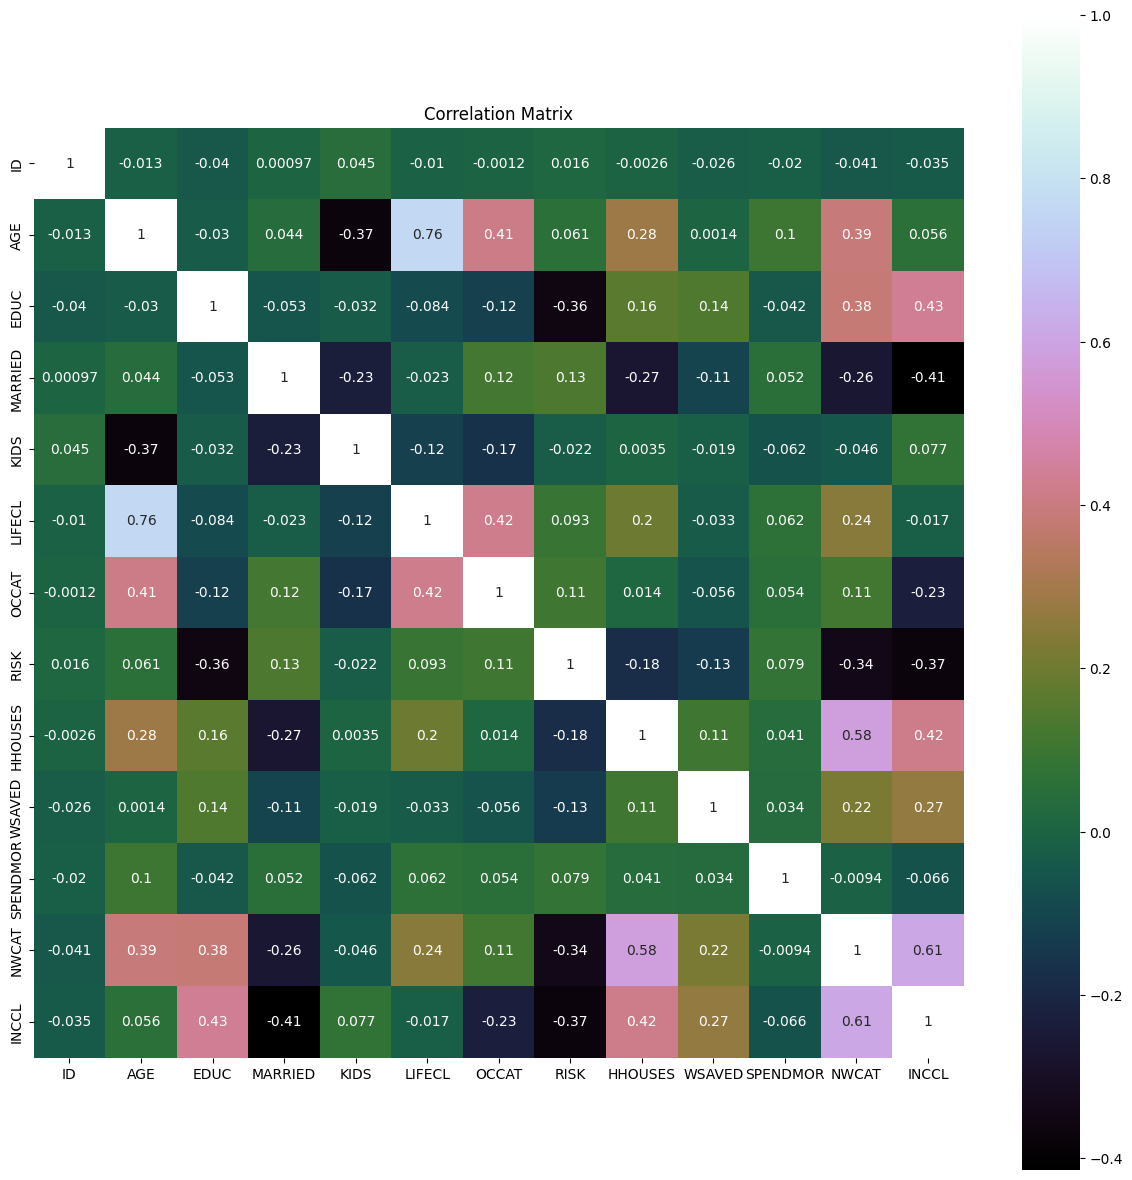

In [ ]:
correlation = dataset.corr()
plt.figure(figsize=(15,15))
plt.title('Correlation Matrix')
sns.heatmap(correlation, vmax=1, square=True,annot=True,cmap='cubehelix')

Nhìn hình trên, các đặc trưng có mối tương quan tích cực đáng kể

# 4. TIỀN XỬ LÝ DỮ LIỆU

## 4.1. LÀM SẠCH DỮ LIỆU
Đầu tiên nhóm sẽ thực hiện kiểm tra các giá trị NA trong các hàng, loại bỏ chúng hoặc điền vào bằng giá trị trung bình của cột.

In [ ]:
print('Null Values =',dataset.isnull().values.any())

Null Values = False


Do không có dữ liệu bị thiếu và dữ liệu đã ở định dạng phân loại nên không cần thực hiện thêm bước làm sạch dữ liệu nào. Cột ID không cần thiết đã được loại bỏ.

In [ ]:
X=dataset.copy("deep")
X=X.drop(['ID'], axis=1)
X.head()

,AGE,EDUC,MARRIED,KIDS,LIFECL,OCCAT,RISK,HHOUSES,WSAVED,SPENDMOR,NWCAT,INCCL
0,3,2,1,0,2,1,3,1,1,5,3,4
1,4,4,1,2,5,2,3,0,2,5,5,5
2,3,1,1,2,3,2,2,1,2,4,4,4
3,3,1,1,2,3,2,2,1,2,4,3,4
4,4,3,1,1,5,1,2,1,3,3,5,5


## 4.2. CHUYỂN ĐỔI DỮ LIỆU

Dữ liệu hiện có bao gồm các thuộc tính có thang đo tương tự. Do đó, không cần thực hiện chuyển đổi dữ liệu.

# 5. ĐÁNH GIÁ CÁC THUẬT TOÁN VÀ MÔ HÌNH

Trong bước này, nhóm sẽ xem xét mô hình K-Means và thực hiện phân tích cũng như trực quan hóa sâu hơn.

## 5.1. PHÂN CỤM K-MEANS


### 5.1.1. TÌM SỐ LƯỢNG CỤM TỐI ƯU

Thông thường, hai chỉ số được sử dụng để đánh giá số lượng cụm trong mô hình K-means là:

1. Tổng bình phương sai số (SSE) trong các cụm.
2. Silhouette score


#### Tổng bình phương sai số (SSE) trong các cụm.

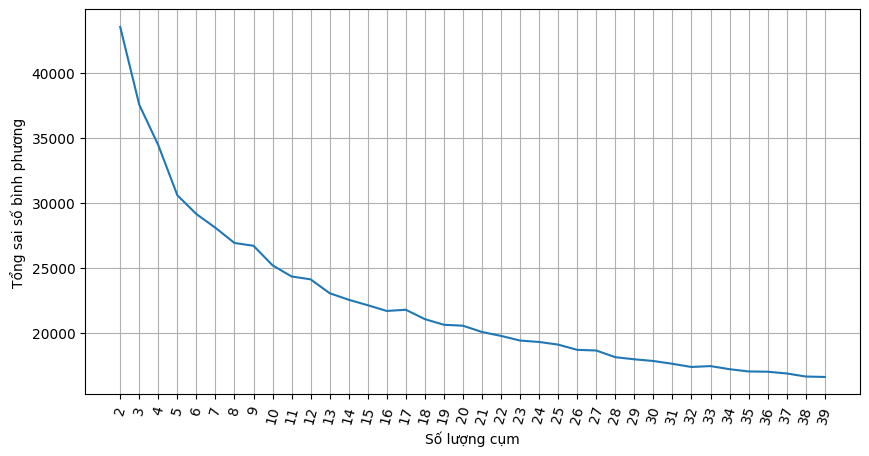

In [ ]:
distorsions = []
max_loop=40
for k in range(2, max_loop):
    k_means = KMeans(n_clusters=k)
    k_means.fit(X)
    distorsions.append(k_means.inertia_)
fig = plt.figure(figsize=(10, 5))
plt.plot(range(2, max_loop), distorsions)
plt.xticks([i for i in range(2, max_loop)], rotation=75)
plt.xlabel("Số lượng cụm")
plt.ylabel("Tổng sai số bình phương")
plt.grid(True)

#### Silhouette score

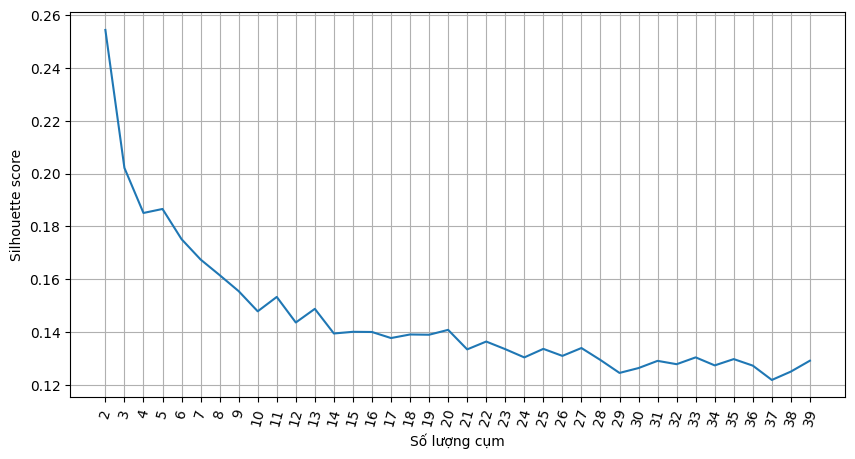

In [ ]:
from sklearn import metrics

silhouette_score = []
for k in range(2, max_loop):
        kmeans = KMeans(n_clusters=k,  random_state=10, n_init=10)
        kmeans.fit(X)
        silhouette_score.append(metrics.silhouette_score(X, kmeans.labels_, random_state=10))
fig = plt.figure(figsize=(10, 5))
plt.plot(range(2, max_loop), silhouette_score)
plt.xticks([i for i in range(2, max_loop)], rotation=75)
plt.xlabel("Số lượng cụm")
plt.ylabel("Silhouette score")
plt.grid(True)

Nhìn vào cả hai biểu đồ ở trên, số lượng cụm tối ưu dường như là khoảng 7, có thể thấy rằng khi số lượng cụm tăng lên quá 6, tổng bình phương sai số trong các cụm thường ổn định.

Từ biểu đồ thứ hai, có thể thấy rằng có nhiều điểm uốn trên biểu đồ. Vì không có nhiều sự khác biệt về SSE sau 7 cụm, nhóm quyết định sẽ sử dụng 7 cụm trong mô hình K-Means.

### 5.1.2. PHÂN CỤM VÀ TRỰC QUAN HÓA

In [ ]:
nclust=7

In [ ]:
k_means = cluster.KMeans(n_clusters=nclust)
k_means.fit(X)

,n_clusters,7
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [ ]:
target_labels = k_means.predict(X)

## 5.2. ĐÁNH GIÁ PHÂN CỤM

Đánh giá các cụm bằng cách sử dụng hệ số silhouette. hệ số silhouette score càng cao thì mô hình càng có các cụm được xác định rõ ràng hơn.

In [ ]:
from sklearn import metrics
print("km", metrics.silhouette_score(X, k_means.labels_, metric='euclidean'))

km 0.1626980256320611


Thuật toán K-Means có hệ số Silhouette cao và ổn định.

# 6. Ý NGHĨA CỦA CÁC CỤM

Ở phần này, nhóm sẽ kiểm tra từng cụm và hiểu được ý nghĩa đằng sau các cụm đó.

In [ ]:
cluster_output= pd.concat([pd.DataFrame(X), pd.DataFrame(k_means.labels_, columns = ['cluster'])],axis = 1)
output=cluster_output.groupby('cluster').mean()
output

,AGE,EDUC,MARRIED,KIDS,LIFECL,OCCAT,RISK,HHOUSES,WSAVED,SPENDMOR,NWCAT,INCCL
cluster,,,,,,,,,,,,
0,4.656,3.350,1.245,0.316,5.346,2.048,2.857,0.947,2.635,4.538,4.367,4.331
1,1.913,2.420,1.292,2.026,3.292,1.420,3.278,0.505,2.215,1.991,1.788,3.222
2,1.911,2.467,1.315,2.128,3.337,1.428,3.361,0.533,2.257,4.521,1.765,3.169
3,1.963,2.895,1.618,0.002,1.384,1.515,3.151,0.458,2.411,3.570,1.940,3.100
4,4.882,2.070,1.595,0.185,5.660,2.441,3.585,0.682,2.232,3.932,2.258,2.585
5,2.454,3.539,1.135,1.559,2.737,1.446,2.477,0.943,2.706,3.504,4.247,4.717
6,4.599,3.488,1.245,0.368,5.324,2.046,2.717,0.932,2.569,2.084,4.411,4.507


### ĐẶC ĐIỂM NHÂN KHẨU HỌC

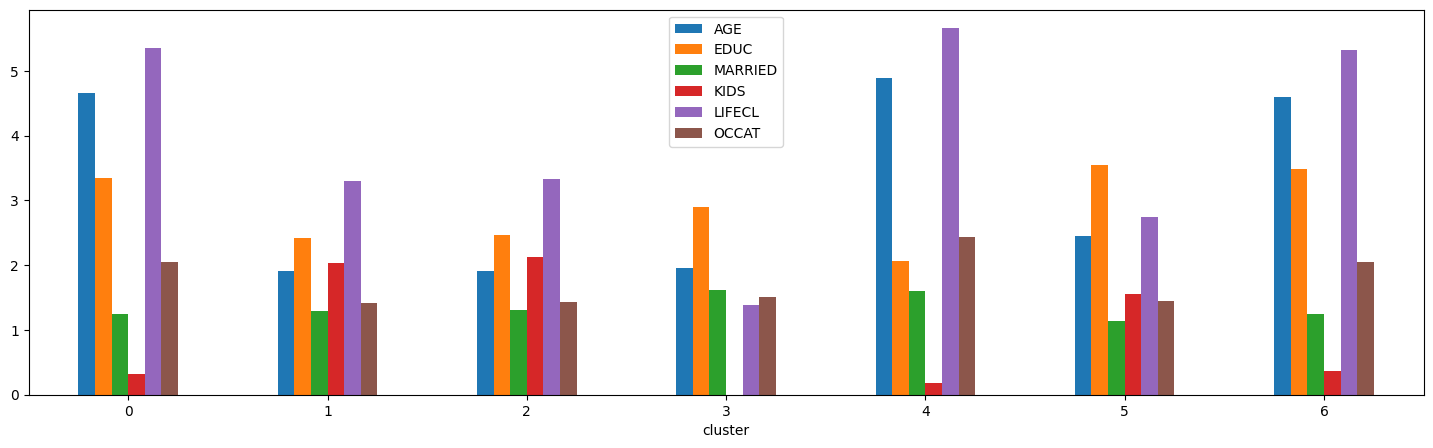

In [ ]:
output[['AGE','EDUC','MARRIED','KIDS','LIFECL','OCCAT']].plot.bar(rot=0, figsize=(18,5));

Biểu đồ ở đây thể hiện giá trị trung bình của các thuộc tính cho mỗi cụm.

Cụ thể, khi so sánh cụm 0 và cụm 1, cụm 0 có độ tuổi trung bình cao hơn và trình độ học vấn trung bình cũng cao hơn.

Về hôn nhân và số con, hai cụm này có sự khác biệt nhau, khi cụm 0 có số con ít hơn, còn cụm 1 có số con nhiều hơn, hôn nhân tương đồng nhau.

Vì vậy, dựa trên các thuộc tính nhân khẩu học, các cá nhân trong cụm 1 trung bình sẽ có khả năng chịu rủi ro cao hơn so với các cá nhân trong cụm 0.

### CÁC ĐẶC ĐIỂM TÀI CHÍNH VÀ ĐẶC ĐIỂM LIÊN QUAN ĐẾN KHẢ NĂNG CHẤP NHẬN RỦI RO

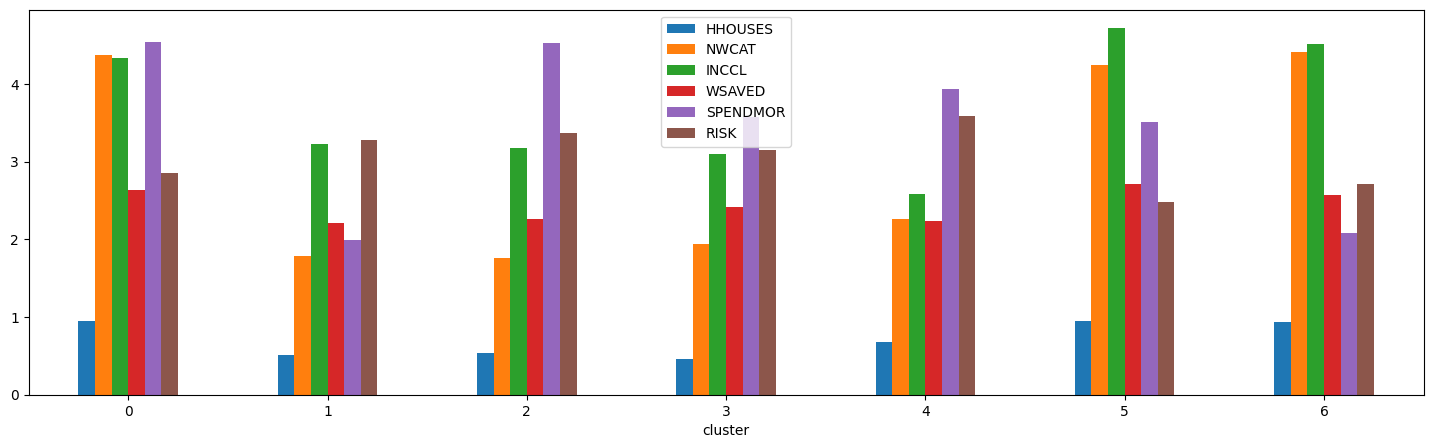

In [ ]:
output[['HHOUSES','NWCAT','INCCL','WSAVED','SPENDMOR','RISK']].plot.bar(rot=0, figsize=(18,5));

Biểu đồ ở đây thể hiện giá trị trung bình của các thuộc tính cho mỗi nhóm về các thuộc tính tài chính và hành vi.

Cụ thể, khi so sánh cụm 0 và cụm 1, cụm 0 có tỷ lệ sở hữu nhà trung bình cao hơn. Giá trị tài sản ròng và thu nhập trung bình cao hơn và mức độ sẵn sàng chấp nhận rủi ro thấp hơn.

Về so sánh giữa tiết kiệm và thu nhập cũng như mức độ sẵn sàng tiết kiệm, cụm 0 có tiết kiệm tương đối cao hơn cụm 1, còn thu nhập và mức độ sẵn sàng tiết kiệm cao hơn hoàn toàn so với cụm 1.

Do đó, có thể giả định rằng, trung bình, các cá nhân trong cụm 0 sẽ có khả năng chấp nhận rủi ro cao hơn, nhưng mức độ sẵn sàng chấp nhận rủi ro thấp hơn so với cụm 1.

<Axes: xlabel='cluster'>

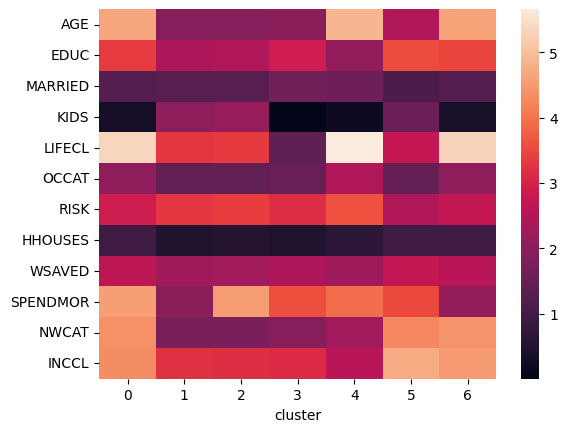

In [ ]:
sns.heatmap(output.T)

Dựa vào cụm 0, thấy các biến AGE, NWCAT và INCCL đều có màu cam sáng, cho thấy đây là nhóm khách hàng lớn tuổi, có khối tài sản và thu nhập rất cao.
Ngược lại, cụm 1 hiển thị màu tối ở các biến này, đại diện cho nhóm khách hàng trẻ tuổi và chưa tích lũy được nhiều tài sản.
Đặc biệt ở biến RISK. Cụm 0 dù rất giàu có nhưng dải màu RISK lại tối hơn đáng kể so với cụm 1.
Thực hiện phân tích tương tự trên tất cả các nhóm khác, nhóm tóm tắt kết quả trong bảng dưới đây:

(Cột "Mức độ chấp nhận rủi ro" thể hiện đánh giá chủ quan về mức độ chấp nhận rủi ro của mỗi cụm)
| Cụm| Đặc trưng qua dải màu | Risk Capacity |
| --- | --- | --- |
| Cụm 0	 | Lớn tuổi, tài sản và thu nhập cao, không có con, chi tiêu cao, mức độ sẵn sàng chấp nhận mạo hiểm thấp. | Cao |
| Cụm 1		 | Trẻ tuổi, tài sản thấp, thu nhập trung bình thấp, ít chi tiêu, mức độ sẵn sàng chấp nhận mạo hiểm cao. | Thấp |
| Cụm 2		 | Trẻ tuổi, tài sản thấp, chi tiêu rất cao, mức độ sẵn sàng chấp nhận mạo hiểm cao. | Thấp |
| Cụm 3		 | Trẻ tuổi, tài sản thấp, không có con, giai đoạn đầu vòng đời, mức độ sẵn sàng chấp nhận mạo hiểm bình thường. | Thấp |
| Cụm 4		 | Lớn tuổi, học vấn thấp, tài sản và thu nhập thấp, mức độ sẵn sàng chấp nhận mạo hiểm cao nhất. | Thấp |
| Cụm 5		 | Lớn tuổi, học vấn cao, tài sản và thu nhập cực kỳ cao, mức độ sẵn sàng chấp nhận mạo hiểm thấp. | Rất cao |
| Cụm 6		 | Lớn tuổi, học vấn cao, tài sản và thu nhập cao, không có con, mức độ sẵn sàng chấp nhận mạo hiểm thấp. | Cao |

**KẾT LUẬN**

Kỹ thuật trực quan hóa giúp diễn giải định tính hiệu quả các biến số, phác họa rõ nét hành vi kỳ vọng của từng nhóm khách hàng.

Thuật toán đã nhóm thành công các nhà đầu tư. Dữ liệu thực tế phát hiện ra nghịch lý, nhóm có năng lực chịu rủi ro cao (tài sản lớn) lại e ngại mạo hiểm, trong khi nhóm tài sản thấp lại sẵn sàng liều lĩnh hơn.

Việc thấu hiểu hành vi này giúp các nhà quản lý chuẩn hóa việc phân bổ tài sản và tái cân bằng danh mục cho từng cụm, giúp quá trình đầu tư nhanh chóng và hiệu quả hơn.